# Простые задачи управления


In [1]:
import numpy as np
import scipy.optimize as sciopt

import matplotlib.pyplot as plt


В этом ноутбуке мы рассмотрим очень простую задачу, чтобы лучше понять, что нам может быть инетерсно искать и почему это больше, чем просто оптимизация.

## Постановка

Мы проектируем систему климат-контроля (проще -- кондиционер), которая должна за время $T$ привести температуру $X_*$ (для технической простоты положим $X*=0$). Через систему вентилляции комната совершает теплообмен с окружающей средой, физически это описывается уравнением Ньютона

$$
\dot{X} = r(X_{env}-X),
$$
где $r>0$ -- константа, определяющая скорость охлаждения (зависит только от среды), а $X_{env}$-- температура окружающей среды. Самый простой способ учесть какую-то неопределённость в изменении температуры приводит к уравнению процесса Орнштейна-Уленбека такого типа:

$$
dX_t = r(X_{env}-X_t)dt + \sigma_0 dW_t.
$$

Нам дана возможность искусственно изменять температуру с помощью системы климат-контроля. Естественно, что она никак не влияет на случайную составляющую, но влияет на снос:

$$
dX_t = [r(X_{env}-X_t) + u_t]dt + \sigma_0 dW_t.
$$

Главный критерий -- мягкое попадание в целевую температуру (жёстко мы не можем из-за шума) и минимизация затраченных усилий:

$$
\min_u \mathbb{E}\left[ \gamma_1X_T^2 + \gamma_2\int_{0}^T u_t^2 dt \right], ~ \gamma_1,\gamma_2>0.
$$

Модель в непрерывном времени мы рассмотрим на доске. 

В дискретном времени ситуация другая -- аналитически всё сильно сложнее, но для (достаточно мощного во всяком случае) компьютера наоборот.

## Модель в дискретном времени

Простейшая модель, с которой можно начать -- это модель авторегрессии с управлением в сносе:

$$
X_{t+1} = \mu + aX_t + v_t + \varepsilon_{t+1}, ~~ \varepsilon_{t} \sim_{iid} N(0,\sigma^2),
$$
где
$$
\mu=rX_{env}\Delta t, ~~ a = (1-r)\Delta t, ~~ v_t = u_t \Delta t, ~~ \sigma^2=\sigma_0^2 \Delta t.
$$

Критерий очень похож:
$$
\min_u \mathbb{E}\left[ \gamma_1X_T^2 + \gamma_2\sum_{t=0}^{T-1} v_t^2  \right].
$$

В этой постановке всё предельно просто и мы уже сейчас можем построить метод. В частных случаях $u_t$ на бумаге, а в общем -- путём градиентной оптимизации.

Класс управлений задаётся техническими возможностями. Обычно инженер-конструктор имеет несколько разных идей, которые можно реализовать в железе и каждую из них нужно оптимально настроить, чтобы понять наилучший возможный эффект и потом выбрать лучшую опцию. Возможные варианты:

1. $u_t=u_0=const$, ничего не требует, просто собрать аналоговую схему.
2. $u_t=u(t)$, детерминированное разомкнутое управление, для этого возможно пригодится немного простой электроники типа микроконтроллера.
3. $u_t=\alpha X_t$, управление с линейной обратной связью, микроконтроллер тоже такое может, а ещё
4. он может и чуть более сложное вроде $u_t=\sum_{k=0}^p \alpha_p X_{t-p}$ или $u_t=\beta t + \sum_{k=0}^p \alpha_p X_{t-p}$.

Вопрос: что из этого лучше?

## Симулятор

Начнём с управления, для рассматриваемых классов нам нужна достаточно общая модель.

`Код частично написан с мыслями про VAR, но AR уже получился достаточно интересным) для VAR надо немного допилить`

In [2]:
class Controller:

    def __init__(self):
        pass

    def control(self,t, X):
        """Computes control signal

        Args:
            t (int): current time step
            X (float[]): history tensor (N,K,d)

        Returns:
            control: (N,d)
        """ 
        raise NotImplementedError
    
class ConstController(Controller):

    def __init__(self, u=None):
        super().__init__()
        self.u = u

    def control(self, t, X):
        """Computes control signal

        Args:
            t (int): current time step
            X (float[]): history tensor (N,K,d)

        Returns:
            control: (N,d)
        """ 
        return self.u
    
class DeterministicController(Controller):

    def __init__(self, uFun=None):
        super().__init__()
        self.uFun = uFun

    def control(self, t, X):
        """Computes control signal

        Args:
            t (int): current time step
            X (float[]): history tensor (N,K,d)

        Returns:
            control: (N,d)
        """ 
        return self.uFun(t)
    
class OrderPLinearFeedbackController(Controller):

    def __init__(self, order, alphas=None):
        super().__init__()
        self.order = order
        self.alphas = alphas

    def control(self, t, X):
        """Computes control signal

        Args:
            t (int): current time step
            X (float[]): history tensor (N,K,d)

        Returns:
            control: (N,d)
        """        
        return np.einsum("nkd,k->nd",X[...,-self.order:],self.alphas)

In [3]:
#back to school
class VAR1Simulator:

    def __init__(self, mu, A, Rx):
        """VAR(1) simulator

        The model is 
        X_{t+1} = mu + A X_t + v_t + epsilon_{t+1},  epsilon_t ~iid N(0,Rx)

        Args:
            mu (float[]): drift parameter (d,)
            A (float[]): dynamics matrix (d,d)
            Rx (float[]): noise covariance (d,d)
        """        
        self.mu = mu
        self.A=A
        self.Rx=Rx

    def generate(self, T, start, controller=None):
        """Generates signal and measurements. If controller is None, then zero controller is implemented by default.

        Args:
            T (int): signal length
            start (float[]): start state X_0 (N,d)
            controller (Controller): Controller instance implementing control. Defaults to: None

        Returns:
            float[] Xs, float[] controls: (N,d,T) signal, (N,d,T-1) control signal
        """        

        if(controller is None):
            #no control
            controller = ConstController(np.zeros([start.shape[1]]))

        Xs = np.zeros([start.shape[0],start.shape[1],T]) 
        controls = np.zeros([Xs.shape[0],Xs.shape[1],T-1])

        Xs[...,0] = start
        print(T)
        for i in np.arange(1,T):
            controls[...,i-1] = controller.control(i-1,Xs[...,:(i)])
            Xs[...,i] = self.evolution(Xs[...,i-1], controls[...,i-1] )
            
        return Xs, controls
    
    def evolution(self, x, control):
        """Performs an update, time evolution

        Args:
            x (float[]): current state (N,d)
            control (float[]): generated control (N,d)

        Returns:
            float[] X: new state (N,d)
        """        
        return self.mu + np.einsum("mp,np->nm",self.A, x) + control + np.random.multivariate_normal( np.zeros([self.A.shape[0]]), self.Rx,size=x.shape[0])

Проверим, что в симуляторе всё работает.

In [4]:
mu = np.array([0.1])
A = np.array([[0.95]])
sigma = np.array([[0.2]])
x0 = np.array([[1],[3],[0.2]])

sim = VAR1Simulator(mu,A,sigma)


In [5]:
T=50
#contr = ConstController(u=np.array([[-0.8],[-0.8],[-0.8]]))
contr = OrderPLinearFeedbackController(order=1,alphas=np.array([0.1]))
trajs, _ = sim.generate(T,x0,controller=contr) 

50


In [6]:
def plotTrajs(trajs, title, controls=None):

    if(controls is None):
        f,ax = plt.subplots(figsize=(7,5))

        ax.grid()
        ax.set_title(title,fontsize=16)
        ax.set_xlabel("t",fontsize=14)
        ax.plot(trajs[:,0,:].T)
    else:
        f,ax = plt.subplots(1,2,figsize=(10,5))

        ax[0].grid()
        ax[0].set_title(title,fontsize=16)
        ax[0].set_xlabel("t",fontsize=14)
        ax[0].plot(trajs[:,0,:].T)
        
        ax[1].grid()
        ax[1].set_title(title+", управления",fontsize=16)
        ax[1].set_xlabel("t",fontsize=14)
        ax[1].plot(controls[:,0,:].T)
        
    return f,ax

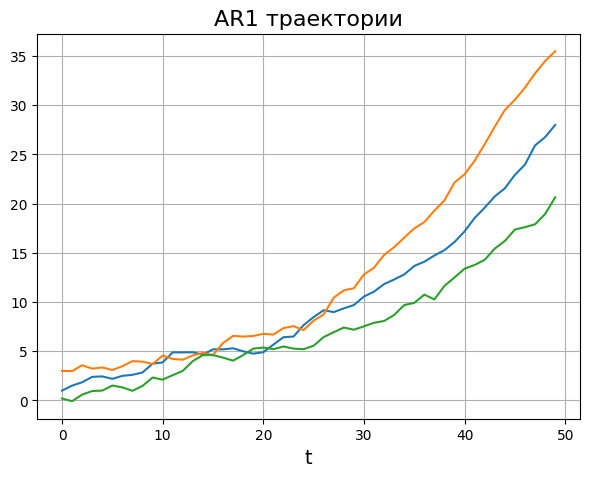

In [7]:
plotTrajs(trajs,"AR1 траектории")
plt.show()

## Тестируем управления

Мы всё ещё не вывели формулы для оптимального управления. В этой задаче мы это можем сделать относительно несложно.

In [8]:
#make trainable versions of controllers TODO

class TrainableConstController(ConstController):
    
    def fit(self, gamma1, gamma2, mu, A, x0, T):
        AA = A[0,0]**(T-1) * np.sum(A[0,0]**(-np.arange(T)))
        self.u = - gamma1*AA*(mu*AA + A**T*x0) / (gamma1*AA**2 + gamma2*T)
        
class TrainableDeterministicController(DeterministicController):
    
    def fit(self, gamma1, gamma2, mu, A, x0, T):
        AA = A[0,0]**(T-1) * np.sum(A[0,0]**(-np.arange(T)))
        Amat = gamma1*A[0,0]**(2*(T-1)-np.arange(T)[:,None]-np.arange(T)[None,:])
        Amat = Amat + gamma2*np.eye(Amat.shape[0])
        bb =  - gamma1*(mu[0]*AA+A[0,0]**T*x0) * A[0,0]**(T-1-np.arange(T))
        print(Amat.shape, bb.shape)
        v = np.concatenate([np.linalg.solve(Amat,bb[k,:])[:,None] for k in np.arange(bb.shape[0])], axis=-1)
        print(v.shape)
        self.vControl=v.T
        def detContFun(t):
            return self.vControl[...,t:t+1]
        self.uFun=detContFun
        

In [9]:
mu = np.array([0.3])
A = np.array([[1.01]])
sigma = np.array([[0.00000000002]])
x0 = np.array([[30],[30],[30],[30],\
                [10],[10],[10],[10]])#np.array([[1],[3],[0.2]])
T=500
gamma1 = 1#target accuracy
gamma2 = 0 #fuel costs

sim = VAR1Simulator(mu,A,sigma)

constControl = TrainableConstController()
constControl.fit(gamma1,gamma2,mu,A,x0,T)

detControl = TrainableDeterministicController()
detControl.fit(gamma1,gamma2,mu,A,x0,T)

(500, 500) (8, 500)
(500, 8)


In [10]:
trajsZero, _ = trajsConst, controlsConst = sim.generate(T,x0)
trajsConst, controlsConst = sim.generate(T,x0,constControl)
trajsDet, controlsDet = sim.generate(T,x0,detControl)
print(trajsConst.shape)
print(trajsDet.shape)

500
500
500
(8, 1, 500)
(8, 1, 500)


(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: title={'center': 'AR1 траектории (u=u(t))'}, xlabel='t'>,
        <Axes: title={'center': 'AR1 траектории (u=u(t)), управления'}, xlabel='t'>],
       dtype=object))

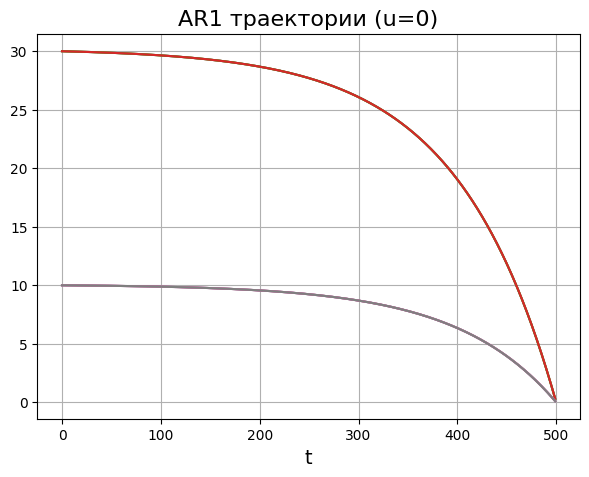

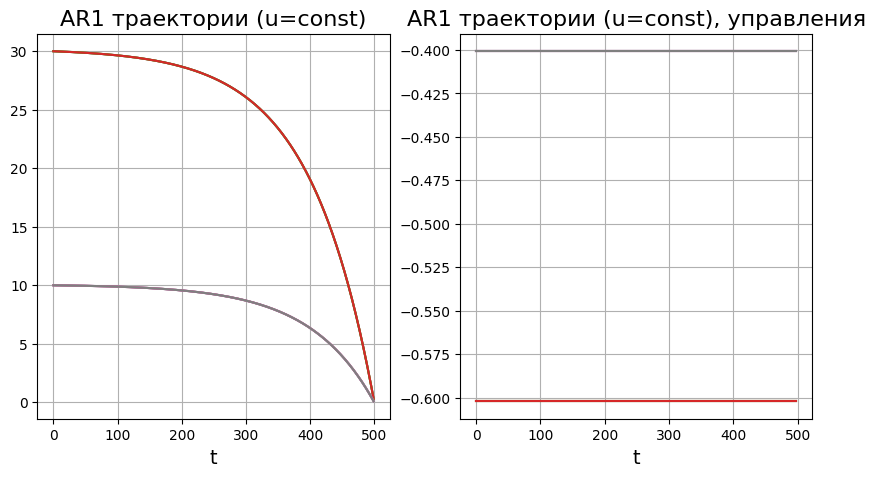

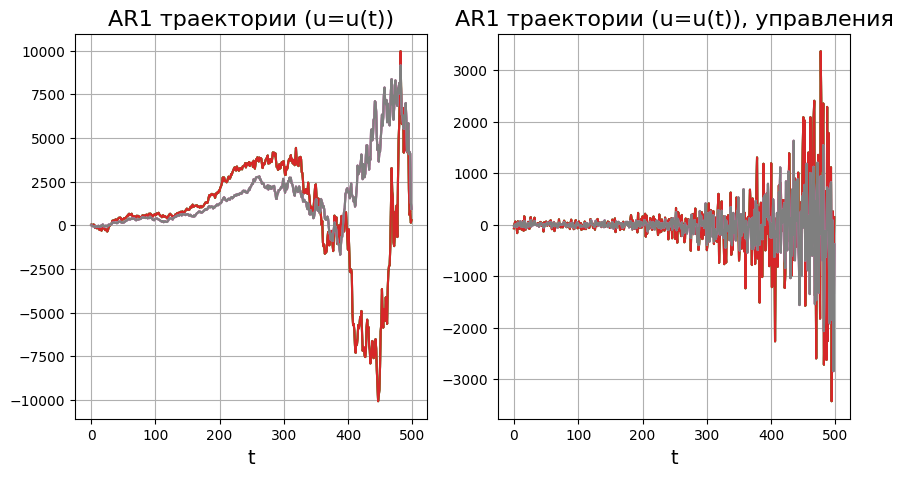

In [11]:
plotTrajs(trajsConst, title="AR1 траектории (u=0)")
plotTrajs(trajsConst,controls=controlsConst, title="AR1 траектории (u=const)")
plotTrajs(trajsDet,controls=controlsDet, title="AR1 траектории (u=u(t))")

Интересно сравнить сценарии с разным уровнем шума. В детерминированном случае задача решается достаточно хорошо и мы уверенно приходим в окресстность нуля. Однако даже небольшое количество шума со временем экспоненциально растёт и ломает стратегию управления. Зависимость от времени никак не помогает.

Очень интересно также посмотреть на характер $u(t)$, на самом деле управление такого типа с технической стороны не удивительно и есть реальные устройства которые действительно генерируют похожий периодический сигнал. Поумайте, что это могло бы быть.

Причина, по которой в условиях шума всё ломается, -- это то, что сам шум не наблюдаем, но его можно учесть, используя в управлении $X_t$, то есть, обратную связь.

Попробуйте сценарий с оооочень маленьким `sigma` и с разными параметрами авторегрессии `A`.

## Добавляем обратную связь

Линейная обратная связь задаётся в виде $v_t = \alpha X_t$. Наша задача теперь -- подобрать оптимальный $\alpha$. Путей много, мы попробуем воспользоваться для начала простым ``scipy.optimize``.

In [12]:
class TrainableOrderPLinearFeedbackController(OrderPLinearFeedbackController):
    
    def fit(self, gamma1, gamma2, mu, sigma, A, x0, T):
        #sigma is sigma^2
        # x0 (N,1)
        def loss(alpha):
            Et=x0
            Ett=[np.zeros_like(x0)]
            for _ in np.arange(1,T+1):
                #print(mu.shape, sigma.shape, Et[-1].shape, Ett[-1].shape)
                #print(  ((mu**2+sigma) + (A+alpha)**2 * Ett + 2*mu*(A+alpha)*Et).shape  )
                Ett.append( (mu**2+sigma) + (A+alpha)**2 * Ett[-1] + 2*mu*(A+alpha)*Et )
                Et = mu + (A+alpha)*Et
            return gamma1*Ett[-1][0,0] + gamma2*alpha**2*np.sum(Ett[:-1])
        
        alphaS = sciopt.minimize_scalar(loss,bounds=(-1,0.5)).x
        self.alphas = np.array([alphaS])
            
            

In [13]:
mu = np.array([0.8])
A = np.array([[1.01]])
sigma = np.array([[0.2]])
x0 = np.array([[30],[30],[30],[30],\
                [10],[10],[10],[10]])#np.array([[1],[3],[0.2]])
T=500
gamma1 = 1#target accuracy
gamma2 = 1e-1 #fuel costs

sim = VAR1Simulator(mu,A,sigma)

constControl = TrainableConstController()
constControl.fit(gamma1,gamma2,mu,A,x0,T)

detControl = TrainableDeterministicController()
detControl.fit(gamma1,gamma2,mu,A,x0,T)

feedbackControl = TrainableOrderPLinearFeedbackController(order=1)
feedbackControl.fit(gamma1,gamma2,mu,sigma,A,x0,T)

(500, 500) (8, 500)
(500, 8)


In [14]:
trajsZero, _ = trajsConst, controlsConst = sim.generate(T,x0)
trajsConst, controlsConst = sim.generate(T,x0,constControl)
trajsDet, controlsDet = sim.generate(T,x0,detControl)

trajsFeedback, controlsFeedback = sim.generate(T,x0,feedbackControl)

500
500
500
500


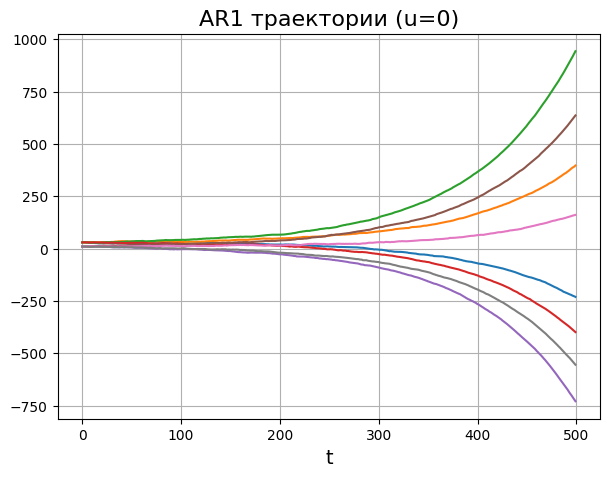

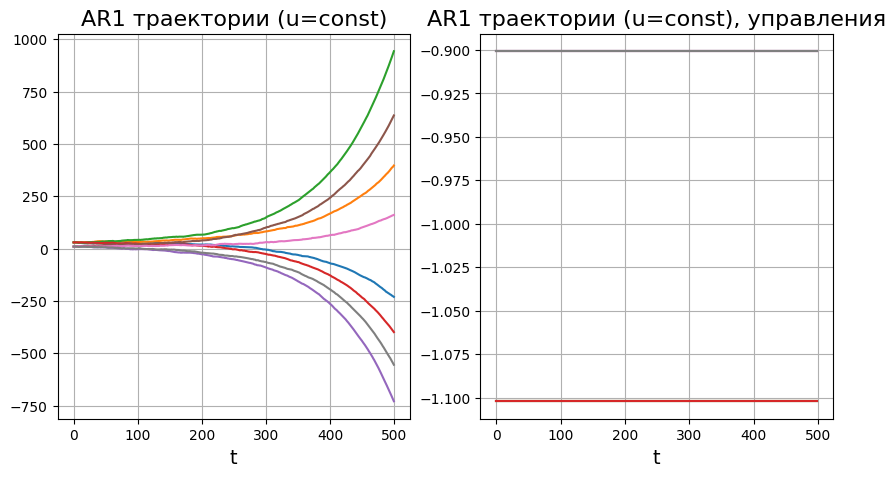

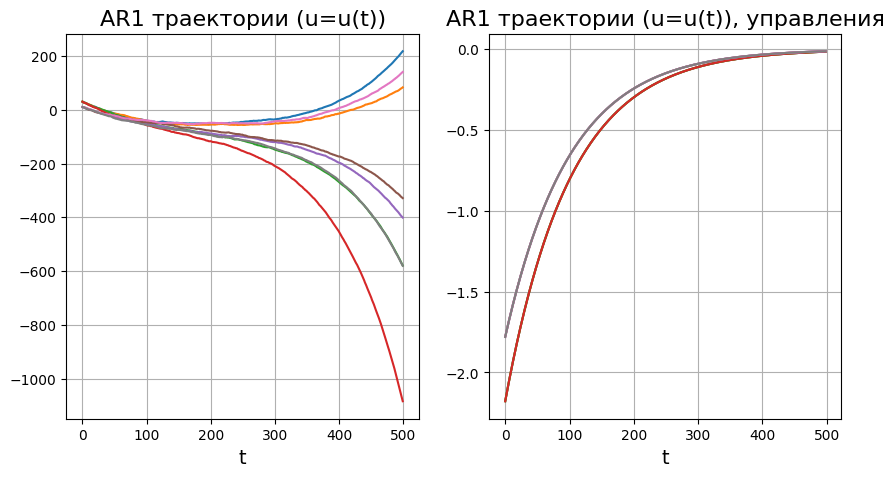

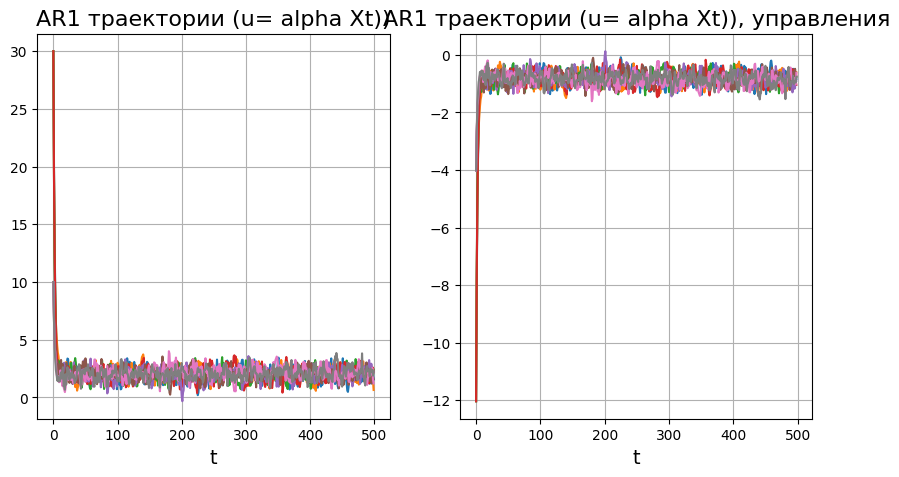

In [15]:
#trajs
plotTrajs(trajsConst, title="AR1 траектории (u=0)")
plotTrajs(trajsConst,controls=controlsConst, title="AR1 траектории (u=const)")
plotTrajs(trajsDet,controls=controlsDet, title="AR1 траектории (u=u(t))")
plotTrajs(trajsFeedback,controls=controlsFeedback, title="AR1 траектории (u= alpha Xt))")

#log error
def logabs(x):
    return np.log(np.abs(x))
#plotTrajs(logabs(trajsConst), title="AR1(u=0) (лог-ошибки)")
#plotTrajs(logabs(trajsConst),controls=controlsConst, title="AR1 (u=const) (лог-ошибки)")
#plotTrajs(logabs(trajsDet),controls=controlsDet, title="AR1 (u=u(t)) (лог-ошибки)")
#plotTrajs(logabs(trajsFeedback),controls=controlsFeedback, title="AR1 (u= alpha Xt)) (лог-ошибки)")

Эффект принципиально другой.

Главный вопрос теории -- это как строить управления, которые отвечают критерию оптимальности и способны при этом максимально учитывать характер случайных возмущений.

Оказывается, в этой задаче есть аналитическая формула для правильного $\alpha$, которую мы получим позже. Если же пытаться его подгонять градиентной оптимизацией, то это может быть не так просто, как показывает график функции потерь ниже. Ситуация для численной оптимизации может стать ещё хуже, если обратная связь нелинейная.


In [16]:
feedbackControl.alphas

array([-0.40131502])

In [17]:
def lossExternal(alpha):
    Et=x0[0,0]*np.ones_like(alpha)
    Ett=[0*alpha[:,None]]
    for _ in np.arange(1,T+1):
        print(Et.shape, Ett[-1].shape)
        Ett.append( ((mu[0]**2+sigma[0,0]) + (A[0,0]+alpha)**2 * Ett[-1][:,0] + 2*mu[0]*(A[0,0]+alpha)*Et )[:,None] )
        Et = mu[0] + (A[0,0]+alpha)*Et
    print(Ett[-1])
    print(np.sum( np.concatenate(Ett[:-1],axis=-1),axis=-1))
    return gamma1*Ett[-1][0,0] + gamma2*alpha**2*np.sum( np.concatenate(Ett[:-1],axis=-1),axis=-1)

alphas = np.linspace(-0.6,-0.01,10000)
ls = lossExternal(alphas)


(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)
(10000,) (10000, 1)


-0.34037403740374034


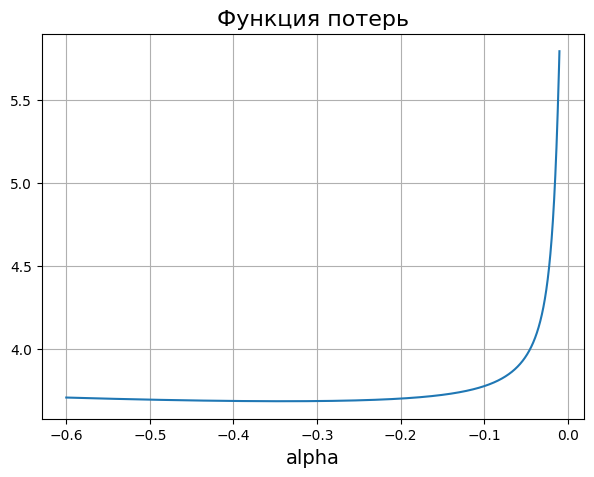

In [18]:
f,ax = plt.subplots(figsize=(7,5))

ax.grid()
ax.set_title("Функция потерь",fontsize=16)
ax.set_xlabel("alpha",fontsize=14)
ax.plot(alphas,np.log(ls))

print(alphas[np.argmin(ls)])